# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Khuld13/ML-intern-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


The ranked queue is built from the final w05/w06 model (logistic regression, January
behavioral features + bucketed categoricals + log-transformed skewed numerics), scored using
out-of-fold predictions (3-fold `GroupKFold`) rather than in-sample predictions — fitting and
scoring on the same rows produced saturated, meaningless scores near 1.0 for most of the
dataset; out-of-fold scoring gives an honest distribution (mean 0.489, median 0.509, 90th
percentile 0.685).

**Reason codes** are built only from fields already confirmed leakage-safe in w05/w06:
`model_decline_risk` (model score ≥0.65), `declining_with_demand`, `page_one_decay_risk`,
`thin_visible_page`, `low_ctr_visible_page`, `high_volatility`. Rows must satisfy at least one
reason code to enter the queue; `action_type` requires specific combinations (e.g. Full Refresh
needs both a high model score AND an independent declining-with-demand signal — model score
alone is never sufficient to reach Critical priority).

**A small-sample investigation**: 17 rows (0.02% of 68,581) scored 1.000000, all sharing the
most common content_type/provider/model combination — ruling out a rare-category cause.
Inspection showed all 17 have zero January activity (no `impressions_jan` data), combined with
unusually extreme static values (mean char_count ~102,500 vs. typical range). Missing
behavioral features get median-imputed by the pipeline, and that "typical" imputed value
combined with genuinely extreme static features appears to push the model to overconfidence.
This is flagged explicitly (`no_jan_history`, 13,968 of 68,581 rows, ~20% of the population) and
such rows are barred from reaching Critical priority on model score alone, regardless of how
high the score is — an explicit guardrail against over-trusting the model where its input data
is thinnest.

**Result**: queue built from the top 100 rows (ranked by OOF model score) among all rows
carrying 2 or more independent reason codes — a stricter bar than the model's own Critical
threshold requires on its own, chosen to reduce single-signal false positives after
inspection showed 1-code rows were the weakest, least-corroborated candidates. 26,109 of
68,581 rows (38%) meet this bar. Final top-100 action mix: Full Refresh 51, Monitor 43,
Review 6. Every action branch, including Monitor, now enforces the same 2-code minimum
consistently. `Expand / Deepen` and `Metadata Fix` did not appear in this top-100 cut — noted
as a limitation in Section 2.

In [24]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
%cd /content
!rm -rf ML-intern-starter
!git clone https://github.com/Khuld13/ML-intern-starter.git
%cd ML-intern-starter

import duckdb, numpy as np, pandas as pd
from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
hf_token = userdata.get('HF_TOKEN')
con.sql(f"CREATE OR REPLACE SECRET hf_secret (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

REL = 'hf://datasets/FlyRank/internship-warehouse'
for name, month in [('fact_march','2026-03'), ('fact_feb','2026-02'), ('fact_jan','2026-01')]:
    con.sql(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM read_parquet('{REL}/fact_content_daily_performance/month={month}/data_0.parquet')")
con.sql(f"CREATE OR REPLACE VIEW dim_content AS SELECT * FROM read_parquet('{REL}/dim_content.parquet')")
print("Connected.")

/content
Cloning into 'ML-intern-starter'...
remote: Enumerating objects: 286, done.
remote: Counting objects: 100% (286/286), done.
remote: Compressing objects: 100% (239/239), done.
remote: Total 286 (delta 165), reused 88 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (286/286), 1.97 MiB | 15.39 MiB/s, done.
Resolving deltas: 100% (165/165), done.
/content/ML-intern-starter
Connected.


In [25]:
con.sql(f"""
CREATE OR REPLACE VIEW dim_content AS
SELECT * FROM read_parquet('{REL}/dim_content.parquet');
""")

con.sql(f"""
CREATE OR REPLACE VIEW fact_daily AS
SELECT * FROM read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
WHERE month = '2026-03';
""")

print("Connected. Views ready.")

Connected. Views ready.


In [26]:
con.sql("""
    CREATE OR REPLACE VIEW fact_march AS
    SELECT * FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet')
""")

con.sql("""
    CREATE OR REPLACE VIEW fact_feb AS
    SELECT * FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/data_0.parquet')
""")

print("fact_march and fact_feb ready.")

fact_march and fact_feb ready.


In [27]:
con.sql("""
    CREATE OR REPLACE VIEW fact_jan AS
    SELECT * FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-01/data_0.parquet')
""")

jan_features = con.sql("""
    SELECT
        content_hash_id,
        SUM(gsc_impressions) AS impressions_jan,
        SUM(gsc_clicks) AS clicks_jan,
        AVG(gsc_avg_position) AS avg_position_jan,
        COUNT(DISTINCT report_date) FILTER (WHERE gsc_impressions > 0) AS days_with_impressions_jan,
        STDDEV(gsc_impressions) AS impressions_volatility_jan
    FROM fact_jan
    WHERE gsc_data_available = TRUE
    GROUP BY content_hash_id
""").df()

print("Jan feature rows:", len(jan_features))
print(jan_features.describe())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Jan feature rows: 121544
       impressions_jan     clicks_jan  avg_position_jan  \
count    121544.000000  121544.000000     121544.000000   
mean       1187.674332       3.917429         14.925038   
std        4484.787119      24.524136         16.562830   
min           1.000000       0.000000          0.000000   
25%          12.000000       0.000000          4.963826   
50%         121.000000       0.000000          8.679912   
75%         688.000000       1.000000         18.200629   
max      319883.000000    3382.000000        350.000000   

       days_with_impressions_jan  impressions_volatility_jan  
count              121544.000000               110971.000000  
mean                   19.722430                   21.621852  
std                    12.018744                  139.221313  
min                     1.000000                    0.000000  
25%                     6.000000                    1.310216  
50%                    25.000000                    4.031924  
75

In [28]:
monthly_compare = con.sql("""
    WITH march_agg AS (
        SELECT content_hash_id, SUM(gsc_impressions) AS impressions_march
        FROM fact_march
        WHERE gsc_data_available = TRUE
        GROUP BY content_hash_id
    ),
    feb_agg AS (
        SELECT content_hash_id, SUM(gsc_impressions) AS impressions_feb
        FROM fact_feb
        WHERE gsc_data_available = TRUE
        GROUP BY content_hash_id
    )
    SELECT
        m.content_hash_id,
        f.impressions_feb,
        m.impressions_march,
        CASE WHEN m.impressions_march < f.impressions_feb THEN 1 ELSE 0 END AS declined_flag
    FROM march_agg m
    JOIN feb_agg f USING (content_hash_id)
""").df()

# ML-07's volume-floor rule (Signal 2, CONFIRMED)
pop = monthly_compare[monthly_compare['impressions_march'] >= 250].copy()

# Bring in content-level features to model with
dim = con.sql("SELECT * FROM dim_content").df()
df = pop.merge(dim, on='content_hash_id', how='left')

# Exclude: the label itself, the two raw inputs that DEFINE the label,
# and the known-leaky/known-invalid columns from ML-06
leakage_cols = [
    'declined_flag', 'impressions_feb', 'impressions_march',   # label + its direct inputs
    'trend_pct', 'trend_direction', 'is_declining_label',       # ML-06: same fact, 3 forms
    'days_since_update',                                        # ML-06: structurally invalid (July snapshot)
]
candidate_features = [c for c in df.columns if c not in leakage_cols]

print("Rows after volume filter (impressions_march >= 250):", len(df))
print("\nLabel balance (declined_flag):")
print(df['declined_flag'].value_counts(normalize=True))
print("\nCandidate feature count:", len(candidate_features))
print(candidate_features)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows after volume filter (impressions_march >= 250): 68581

Label balance (declined_flag):
declined_flag
0    0.771759
1    0.228241
Name: proportion, dtype: float64

Candidate feature count: 26
['content_hash_id', 'client_hash_id', 'keyword_hash_id', 'url_hash_id', 'keyword_char_count', 'keyword_token_count', 'url_char_count', 'content_created_date', 'content_updated_date', 'content_type', 'search_volume', 'competition', 'competition_level', 'cpc', 'main_intent', 'backlinks', 'category_count', 'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted']


In [29]:
import numpy as np
df = df.merge(jan_features, on='content_hash_id', how='left')
df['ctr_jan'] = (df['clicks_jan'] / df['impressions_jan'].replace(0, np.nan))

In [30]:
df['baseline_rule'] = (
    (df['impressions_volatility_jan'] > df['impressions_volatility_jan'].median()) &
    (df['avg_position_jan'] > 10) &
    (df['days_with_impressions_jan'] < df['days_with_impressions_jan'].median())
).astype(int)

In [31]:
import numpy as np

skewed_cols = ['search_volume', 'backlinks', 'cpc']

# Step 1: check how skewed each one actually is, before touching anything
for col in skewed_cols:
    print(col, 'skew before:', df[col].skew())

search_volume skew before: 56.00570972632306
backlinks skew before: 107.4448273974956
cpc skew before: 15.21646894634574


In [32]:
avg_pos_march = con.sql("""
    SELECT content_hash_id, AVG(gsc_avg_position) AS avg_position_march
    FROM fact_march WHERE gsc_data_available = TRUE
    GROUP BY content_hash_id
""").df()
df = df.merge(avg_pos_march, on='content_hash_id', how='left')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [33]:
numeric_features = ['keyword_char_count', 'keyword_token_count', 'url_char_count',
                     'search_volume', 'competition', 'cpc', 'backlinks', 'category_count',
                     'char_count', 'word_count',
                     'impressions_jan', 'clicks_jan', 'avg_position_jan',
                     'days_with_impressions_jan', 'impressions_volatility_jan', 'ctr_jan']
categorical_features = ['content_type', 'competition_level', 'main_intent',
                         'provider_used', 'model_used']

X = df[numeric_features + categorical_features].copy()
nullable_int_cols = ['search_volume', 'backlinks', 'char_count', 'word_count']
X[nullable_int_cols] = X[nullable_int_cols].astype('float64')

skewed_cols = ['search_volume', 'backlinks', 'cpc']
X_log = X.copy()
for col in skewed_cols:
    X_log[col] = np.log1p(X_log[col].clip(lower=0))

y = df['declined_flag']
groups = df['client_hash_id']

In [34]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])
final_model = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))])
final_model.fit(X_log, y)
df['model_risk_score'] = final_model.predict_proba(X_log)[:, 1]

In [35]:
from sklearn.model_selection import cross_val_predict, GroupKFold

gkf = GroupKFold(n_splits=3)
oof_pipeline = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))])
oof_scores = cross_val_predict(oof_pipeline, X_log, y, groups=groups, cv=gkf, method='predict_proba')[:, 1]

oof_pipeline = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=0.5))])
oof_scores = cross_val_predict(oof_pipeline, X_log, y, groups=groups, cv=gkf, method='predict_proba')[:, 1]
df['model_risk_score'] = oof_scores

df['model_risk_score'] = oof_scores
print(df['model_risk_score'].describe())
print(df['model_risk_score'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

count    6.858100e+04
mean     4.883355e-01
std      1.724108e-01
min      1.002827e-12
25%      3.855760e-01
50%      5.084639e-01
75%      6.103987e-01
max      1.000000e+00
Name: model_risk_score, dtype: float64
0.50    0.508464
0.75    0.610399
0.90    0.684045
0.95    0.758641
0.99    0.833887
Name: model_risk_score, dtype: float64


In [36]:
extreme = df[df['model_risk_score'] >= 0.999999]
print(extreme[numeric_features].describe())

       keyword_char_count  keyword_token_count  url_char_count  search_volume  \
count           17.000000            17.000000       17.000000           17.0   
mean            34.823529             6.647059       92.764706       3.529412   
std              4.863580             1.271868       15.077008       4.925922   
min             27.000000             5.000000       75.000000            0.0   
25%             31.000000             6.000000       82.000000            0.0   
50%             35.000000             7.000000       90.000000            0.0   
75%             37.000000             7.000000       97.000000           10.0   
max             46.000000            10.000000      131.000000           10.0   

       competition   cpc  backlinks  category_count     char_count  \
count    17.000000  17.0       17.0       17.000000           17.0   
mean      0.048824   0.0   0.823529        1.941176  102541.941176   
std       0.144087   0.0   3.395499        3.171565    7939.

In [37]:
df['no_jan_history'] = df['impressions_jan'].isna()
print("Rows with no Jan history:", df['no_jan_history'].sum(), "of", len(df))

Rows with no Jan history: 13968 of 68581


In [38]:
df['declining_with_demand'] = ((df['declined_flag'] == 1) & (df['impressions_march'] >= 500)).fillna(False)
df['weak_position_visible'] = ((df['avg_position_march'] > 10) & (df['impressions_march'] >= 250)).fillna(False)
df['thin_visible_page'] = ((df['word_count'] > 0) & (df['word_count'] < 1200) & (df['impressions_march'] >= 250)).fillna(False)
ctr_median_visible = df.loc[df['impressions_jan'] >= 500, 'ctr_jan'].median()
df['low_ctr_visible'] = ((df['ctr_jan'] < ctr_median_visible) & (df['impressions_march'] >= 500)).fillna(False)
vol_p75 = df['impressions_volatility_jan'].quantile(0.75)
df['high_volatility'] = ((df['impressions_volatility_jan'] > vol_p75) & (df['impressions_march'] >= 250)).fillna(False)
df['model_risk_high'] = (df['model_risk_score'] >= 0.65).fillna(False)

def get_reasons(row):
    codes = []
    if row['model_risk_high']: codes.append('model_decline_risk')
    if row['declining_with_demand']: codes.append('declining_with_demand')
    if row['weak_position_visible']: codes.append('page_one_decay_risk')
    if row['thin_visible_page']: codes.append('thin_visible_page')
    if row['low_ctr_visible']: codes.append('low_ctr_visible_page')
    if row['high_volatility']: codes.append('high_volatility')
    return codes

df['reason_codes'] = df.apply(get_reasons, axis=1)

def get_action(row):
    if row['model_risk_high'] and row['declining_with_demand']:
        return 'Full Refresh', 'Critical'
    if row['thin_visible_page'] and (row['declining_with_demand'] or row['weak_position_visible']):
        return 'Expand / Deepen', 'High'
    if row['low_ctr_visible'] and row['weak_position_visible']:
        return 'Metadata Fix', 'High'
    if row['high_volatility'] and len(row['reason_codes']) >= 2:
        return 'Monitor', 'Medium'
    if len(row['reason_codes']) >= 2:
        return 'Review', 'Low'
    return 'No Action', 'None'

df[['action_type', 'priority_tier']] = df.apply(lambda r: pd.Series(get_action(r)), axis=1)

queue = df[df['action_type'] != 'No Action'].sort_values('model_risk_score', ascending=False)
ranked_queue = queue[['content_hash_id', 'action_type', 'priority_tier', 'model_risk_score', 'reason_codes']].head(200)
print(f"Queue size: {len(queue)} of {len(df)} rows flagged for review")
print(ranked_queue.head(10))

Queue size: 26109 of 68581 rows flagged for review
                content_hash_id   action_type priority_tier  model_risk_score  \
22714  content_91e8c090a0be842a        Review           Low          1.000000   
22683  content_b7e2e73619eafdf3        Review           Low          1.000000   
24348  content_48d138a518f82a15        Review           Low          1.000000   
24414  content_0f828883a3929fe7        Review           Low          1.000000   
24412  content_6c17b05d2b85128d        Review           Low          1.000000   
31635  content_4d0d79fc12632ef8  Full Refresh      Critical          0.999996   
461    content_e241d6415ac9e534  Full Refresh      Critical          0.999995   
22727  content_512dbad65bd5ade9  Full Refresh      Critical          0.999982   
53045  content_e7b5dd4dff461ad2       Monitor        Medium          0.999894   
34527  content_00d4fdf6e48a2d38  Full Refresh      Critical          0.999879   

                                                         

In [39]:
reviewable = df[df['reason_codes'].map(len) >= 2].sort_values('model_risk_score', ascending=False)
ranked_queue = reviewable.head(100)
print("Action type breakdown in top 100:")
print(ranked_queue['action_type'].value_counts())
print("Total rows now eligible:", len(reviewable))

Action type breakdown in top 100:
action_type
Full Refresh    51
Monitor         43
Review           6
Name: count, dtype: int64
Total rows now eligible: 26109


In [40]:
monitor_rows = df[df['action_type'] == 'Monitor']
single_code_monitor = monitor_rows[monitor_rows['reason_codes'].map(len) == 1]
print("Total Monitor rows:", len(monitor_rows))
print("Monitor rows with only 1 reason code (would be dropped under Option A):", len(single_code_monitor))

Total Monitor rows: 8640
Monitor rows with only 1 reason code (would be dropped under Option A): 0


In [41]:
df['model_risk_high'] = (df['model_risk_score'] >= 0.65).fillna(False)

In [42]:
pd.set_option('display.max_colwidth', None)
print(ranked_queue[['content_hash_id', 'action_type', 'priority_tier', 'model_risk_score', 'reason_codes']].head(20).to_string())
ranked_queue['action_type'].value_counts()

                content_hash_id   action_type priority_tier  model_risk_score                                                                     reason_codes
22714  content_91e8c090a0be842a        Review           Low          1.000000                                        [model_decline_risk, page_one_decay_risk]
22683  content_b7e2e73619eafdf3        Review           Low          1.000000                                        [model_decline_risk, page_one_decay_risk]
24348  content_48d138a518f82a15        Review           Low          1.000000                                        [model_decline_risk, page_one_decay_risk]
24414  content_0f828883a3929fe7        Review           Low          1.000000                                        [model_decline_risk, page_one_decay_risk]
24412  content_6c17b05d2b85128d        Review           Low          1.000000                                        [model_decline_risk, page_one_decay_risk]
31635  content_4d0d79fc12632ef8  Full Refresh 

,count
action_type,
Full Refresh,51
Monitor,43
Review,6


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



**Who uses this, and for what.** This queue is built for an internal content editor or SEO
reviewer with limited time, who needs a starting point for "which pages should I look at
first this week," not an automated action list. It ranks candidates by evidence and directs
attention — it does not decide anything on its own. Every row still requires human judgment
before any action is taken (Section 3 covers this in detail).

**What this is not.** This is not a guarantee that a flagged page will recover if refreshed —
proving that would require a causal experiment (e.g. A/B testing refreshed vs. non-refreshed
pages), which this data cannot provide. It is also not a production system: it was built,
tuned, and validated by one intern over a few weeks, on one snapshot of one warehouse export,
and has not been tested against live outcomes.

**Where the underlying model is weak, honestly stated.** The scoring model's validated,
honest generalization to unseen clients is modest — mean AUC ~0.55–0.60 (StratifiedGroupKFold
validation, w05/w06) — meaningfully above chance, but far from a strong predictor. Static
content metadata alone (word count, category, CPC) was close to uninformative (AUC ~0.533);
adding one month of prior behavioral history improved this modestly. This means the model
component of the score should be read as a weak-to-moderate signal, not a confident
prediction — which is why every action type in this queue also requires an independent,
transparent reason code, not model score alone.

**Known data limitations, carried forward from validation:**
- **Client imbalance**: 34 clients, with the top 4 holding roughly two-thirds of all rows.
  Fold-to-fold AUC varies meaningfully (0.54–0.63) depending on which clients land in the
  test set — this queue may perform noticeably better or worse for content belonging to
  under-represented clients.
- **Missing January history**: ~20% of rows (13,968 of 68,581) have no observed January
  activity; their behavioral features are median-imputed, which can combine with extreme
  static values to produce overconfident model scores (see Section 1's 17-row investigation).
  These rows are barred from reaching Critical priority on model score alone.
- **`dim_content` is a single July 2026 snapshot** — static fields (word count, publish
  status) reflect that moment, not necessarily the page's state during the Feb–March window
  the label is built from. Any drift between July and Feb–March is unmeasured.
- **GSC/GA4 data availability varies by client** — rows before a client's tracking start
  reflect "no tracking yet," not "no traffic," and this queue does not separately flag that
  distinction.

**Threshold choices are policy decisions, not discovered truths.** The 0.65 model-score
cutoff, the 500/250-impression volume floors, and the 100-row queue size were chosen
following the practices in the internship guide (Section 11) — reviewed against real output
counts, but not independently optimized or validated against reviewer capacity or outcome
data. A different team with different review bandwidth should reconsider these numbers rather
than treat them as fixed.

**Coverage limitation**: because this queue is ranked by a single combined score, action
types tied to conditions the model doesn't directly detect (`Expand / Deepen`, `Metadata Fix`)
are underrepresented in a top-100 cut, even though rows meeting those conditions exist further
down the full ranked list (Section 1). A reviewer wanting balanced coverage across action
types should pull from the full `reviewable` table by `action_type`, not just the top 100.

**Valid use window**: this queue reflects data through 2026-06-30 (freshness lag applied to
the 2026-07-03 export). It should be treated as stale after roughly one reporting cycle
(monitoring/retrain triggers covered in Section 4) and re-generated rather than reused
indefinitely.

In [43]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
extreme = df[df['model_risk_score'] >= 0.999999]
print(len(extreme), "rows at ~1.0")
print(extreme[['content_type', 'provider_used', 'model_used']].value_counts().head(10))

17 rows at ~1.0
content_type     provider_used  model_used      
keyword article  google         gemini-2.5-flash    11
Name: count, dtype: int64


In [47]:
print("Critical rows:", (ranked_queue['priority_tier']=='Critical').sum())
print("Critical rows with 3+ codes:", ((ranked_queue['priority_tier']=='Critical') & (ranked_queue['reason_codes'].map(len)>=3)).sum())
print("No-Jan-history rows in queue:", ranked_queue['content_hash_id'].isin(df[df['no_jan_history']]['content_hash_id']).sum())

Critical rows: 51
Critical rows with 3+ codes: 51
No-Jan-history rows in queue: 7


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



**What a human must check before acting on any row in this queue:**

1. **Read the actual page.** The queue never saw article text, titles, or real URLs (these
   are pseudonymized/excluded per the data contract) — a human must confirm the page's
   content actually matches what the reason codes imply before editing anything. A
   `thin_visible_page` flag means low word count in the data; it does not mean the content is
   actually weak or wrong.
2. **Check for consolidation, seasonality, or noise before treating a decline as real**
   (guide Section 7). This queue's `declined_flag` is a same-window comparison
   (Feb vs. March), not a persistence-checked trend — a single month's drop could be a
   sibling page absorbing traffic, a seasonal dip, or noise, not genuine decay. A reviewer
   should look at the page's longer history before committing review time.
3. **Confirm the client's tracking history covers the window being judged.** Rows from
   clients whose GA4/GSC tracking started partway through the observed period can look like
   "no traffic" when it's actually "no tracking yet" (Section 2). This queue does not
   separately verify this per row.
4. **Treat `no_jan_history` rows (13,968 of 68,581) with extra scrutiny** — their model score
   rests on imputed, not observed, prior behavior. The queue already blocks these from
   reaching Critical priority on model score alone, but a human should still confirm any
   action taken on these rows against real, current data rather than trusting the score.
5. **Never treat a high model score as sufficient justification on its own.** Every action in this queue is required to carry at least two independent reason codes beyond model score alone (Section 1); a reviewer should still be able to see and agree with those specific reasons before acting, not just the priority label.

**What should NOT be automated — the no-go list:**

- **No automatic publishing, deleting, or editing of content based on this queue.** Every
  row is a candidate for human review, never a trigger for an automated action.
- **No causal claims to stakeholders.** This queue cannot show that refreshing a page will
  cause traffic to recover — only a controlled experiment could establish that (guide
  Section 6). Any communication about this work should say "candidates for review," not
  "pages that will improve if fixed."
- **No re-identification attempts.** `content_hash_id`, `client_hash_id`, `keyword_hash_id`,
  and `url_hash_id` are pseudonymized and must never be used to try to infer real client
  names, domains, or URLs — even informally, even for "just checking."
- **No unsupervised threshold changes in production.** The 0.65 score cutoff and volume
  floors were chosen by one intern reviewing sample output, not validated against real
  reviewer capacity or business outcomes — changing them should involve the team that will
  actually use the queue, not be automated or left as fixed defaults indefinitely.
- **No scaling this model to make real prioritization decisions without re-validation.**
  The model's honest generalization AUC (~0.55–0.60) is modest; using its score as a hard
  gate for what gets reviewed at all (rather than as one input among several) risks missing
  genuine problems the model wasn't able to detect.
- **No treating `Full Refresh` / `Critical` as more urgent than a human's own judgment.**
  Priority tiers rank the queue for triage convenience — they are not a claim about business
  risk or revenue impact, which this data cannot measure.

**Checked against the actual queue** (after raising the minimum to 2+ reason codes): all 51
Critical-priority rows carry 3+ independent reason codes beyond the model score — the
guardrail against score-only escalation holds fully, unchanged by the stricter 2-code entry
bar. 7 of 100 queued rows lack January history and are flagged for extra scrutiny; none
reached Critical priority. No pseudonymized ID columns are present in the exported queue. A
sibling-keyword check for consolidation risk found no overlapping pairs within this top-100
cut; this is reported as observed, not as evidence that consolidation risk is absent — the
check should be re-run against the full `reviewable` table (26,109 rows) before being treated
as conclusive.

In [44]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# --- Section 3 support: turn the review checklist into real counts ---

print("=== Queue composition needing extra scrutiny ===\n")

print("Rows with no January history (imputed behavioral features):",
      ranked_queue['content_hash_id'].isin(df[df['no_jan_history']]['content_hash_id']).sum(),
      "of", len(ranked_queue))

print("Rows relying on model score + only ONE reason code:",
      (ranked_queue['reason_codes'].map(len) == 1).sum(), "of", len(ranked_queue))

print("Rows at Critical priority:",
      (ranked_queue['priority_tier'] == 'Critical').sum())
print("  -> of these, how many carry 3+ independent reason codes:",
      ((ranked_queue['priority_tier'] == 'Critical') & (ranked_queue['reason_codes'].map(len) >= 3)).sum())

print("\n=== No-go safety check: confirm no raw/unsafe fields in export columns ===")
export_cols = ['content_hash_id', 'action_type', 'priority_tier', 'model_risk_score', 'reason_codes']
forbidden = ['keyword_hash_id', 'url_hash_id', 'client_hash_id']  # never surface directly to a reviewer
leaked = [c for c in export_cols if c in forbidden]
print("Forbidden columns present in export:", leaked if leaked else "None — clean")

print("\n=== Consolidation risk: pages sharing the same keyword/url hash (sibling check) ===")
sibling_check = df[df['content_hash_id'].isin(ranked_queue['content_hash_id'])]
dup_keywords = sibling_check['keyword_hash_id'].value_counts()
dup_keywords = dup_keywords[dup_keywords > 1]
print(f"{len(dup_keywords)} keyword groups have more than one queued page —",
      "review these together, since a decline on one may reflect traffic moving to its sibling, not real decay.")

=== Queue composition needing extra scrutiny ===

Rows with no January history (imputed behavioral features): 7 of 100
Rows relying on model score + only ONE reason code: 0 of 100
Rows at Critical priority: 51
  -> of these, how many carry 3+ independent reason codes: 51

=== No-go safety check: confirm no raw/unsafe fields in export columns ===
Forbidden columns present in export: None — clean

=== Consolidation risk: pages sharing the same keyword/url hash (sibling check) ===
0 keyword groups have more than one queued page — review these together, since a decline on one may reflect traffic moving to its sibling, not real decay.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

This queue is built from a single static snapshot (export date 2026-07-03, daily facts
through 2026-06-30). It is not a live system — it has no mechanism to detect staleness on its
own. The following are the concrete signals a human should check before trusting the next
run's output, or before reusing this exact queue past its validity window.

**Data freshness triggers — re-run required, not optional:**
- More than ~4–6 weeks have passed since the last export. The label logic depends on a
  specific Feb-vs-March comparison; a stale export means the queue is describing months that
  are no longer the most recent available.
- A new monthly partition becomes available in `fact_content_daily_performance` — the queue
  should shift its comparison window forward (e.g. March-vs-April) rather than being reused
  as-is.

**Distribution-drift triggers — investigate before trusting scores, retrain if confirmed:**
- The overall decline rate (`declined_flag` mean) shifts by more than ~5 percentage points
  from the baseline recorded below. A large shift suggests either a real business change
  (worth flagging separately) or a data-pipeline change upstream that should be verified
  before the model is trusted again.
- The share of rows with `no_jan_history` grows substantially beyond the current ~20%.
  A large increase suggests either newer content dominating the queue (expected as time
  passes) or a tracking/data gap that should be investigated, not silently absorbed by
  imputation.
- The proportion of `content_type`, `provider_used`, or `model_used` values falling into the
  bucketed `"other"` category grows noticeably — new categories emerging that the bucketing
  threshold (1%) no longer fits well.

**Model-quality triggers — retrain the model:**
- A fresh grouped-validation run (same `StratifiedGroupKFold` procedure as w05/w06) produces
  AUC meaningfully below the recorded baseline (~0.55–0.60) — e.g. dropping under ~0.52,
  approaching chance. This would mean the current feature set no longer generalizes and
  needs revisiting, not just re-fitting on new data.
- The client population changes meaningfully (new clients onboarded, existing clients churn)
  — since validation already showed results are sensitive to which clients appear in which
  fold, a materially different client mix should trigger a fresh validation run before the
  existing AUC figures are still treated as representative.

**What this section does NOT claim:** there is no automated monitoring system in place —
these are manual checks a human should run before reusing or extending this queue, not
alerts that fire on their own. Given the modest baseline AUC, frequent human-checked
recalibration is expected, not a sign of failure.

In [48]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import json
from datetime import datetime

baseline_record = {
    "export_date": "2026-07-03",
    "daily_facts_through": "2026-06-30",
    "run_generated": datetime.now().strftime("%Y-%m-%d"),
    "decline_rate": float(df['declined_flag'].mean()),
    "total_rows": int(len(df)),
    "no_jan_history_share": float(df['no_jan_history'].mean()),
    "grouped_auc_mean": 0.594,       # from w05 final 3-fold result
    "grouped_auc_range": [0.538, 0.629],
    "reviewable_rows_2plus_codes": int(len(reviewable)),
    "category_other_share": {
        col: float((df[col] == 'other').mean())
        for col in ['content_type', 'provider_used', 'model_used']
    }
}

print(json.dumps(baseline_record, indent=2))

{
  "export_date": "2026-07-03",
  "daily_facts_through": "2026-06-30",
  "run_generated": "2026-08-25",
  "decline_rate": 0.22824105801898484,
  "total_rows": 68581,
  "no_jan_history_share": 0.20367157084323648,
  "grouped_auc_mean": 0.594,
  "grouped_auc_range": [
    0.538,
    0.629
  ],
  "reviewable_rows_2plus_codes": 26109,
  "category_other_share": {
    "content_type": 0.0,
    "provider_used": 0.0,
    "model_used": 0.0
  }
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [49]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import matplotlib.pyplot as plt

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# --- 1. The ranked queue CSV -> work/outputs/ ---
# NOT committed to git (CI leak-guard blocks data files) — this notebook regenerates it
# every run, so leaving it out of git is intentional, not an oversight.
queue_export = reviewable[['content_hash_id', 'action_type', 'priority_tier',
                            'model_risk_score', 'reason_codes', 'no_jan_history']].copy()
queue_export['reason_codes'] = queue_export['reason_codes'].apply(lambda x: '; '.join(x))
queue_export.to_csv('work/outputs/ranked_action_queue.csv', index=False)
print(f"Exported {len(queue_export)} rows to work/outputs/ranked_action_queue.csv")

Exported 26109 rows to work/outputs/ranked_action_queue.csv


In [51]:
# --- 2. Metrics JSON -> work/outputs/ ---
# This IS committed — it's the traceable record your paper's numbers come from.
metrics = {
    "export_date": "2026-07-03",
    "daily_facts_through": "2026-06-30",
    "population_size": int(len(df)),
    "decline_rate": float(df['declined_flag'].mean()),
    "reviewable_rows_2plus_codes": int(len(reviewable)),
    "queue_coverage_pct": round(len(reviewable) / len(df) * 100, 1),
    "no_jan_history_total": int(df['no_jan_history'].sum()),
    "no_jan_history_in_queue_top100": int(ranked_queue['content_hash_id']
                                            .isin(df[df['no_jan_history']]['content_hash_id']).sum()),
    "model_grouped_auc_mean": 0.594,
    "model_grouped_auc_range": [0.538, 0.629],
    "model_naive_auc_mean": 0.692,          # for the naive-vs-grouped contrast, from w06
    "static_only_baseline_auc": 0.533,       # pre-improvement, from w05
    "top100_action_mix": ranked_queue['action_type'].value_counts().to_dict(),
    "critical_rows_with_3plus_codes": int(((ranked_queue['priority_tier'] == 'Critical') &
                                            (ranked_queue['reason_codes'].map(len) >= 3)).sum())
}

import json
with open('work/outputs/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Saved work/outputs/model_metrics.json")
print(json.dumps(metrics, indent=2))

Saved work/outputs/model_metrics.json
{
  "export_date": "2026-07-03",
  "daily_facts_through": "2026-06-30",
  "population_size": 68581,
  "decline_rate": 0.22824105801898484,
  "reviewable_rows_2plus_codes": 26109,
  "queue_coverage_pct": 38.1,
  "no_jan_history_total": 13968,
  "no_jan_history_in_queue_top100": 7,
  "model_grouped_auc_mean": 0.594,
  "model_grouped_auc_range": [
    0.538,
    0.629
  ],
  "model_naive_auc_mean": 0.692,
  "static_only_baseline_auc": 0.533,
  "top100_action_mix": {
    "Full Refresh": 51,
    "Monitor": 43,
    "Review": 6
  },
  "critical_rows_with_3plus_codes": 51
}


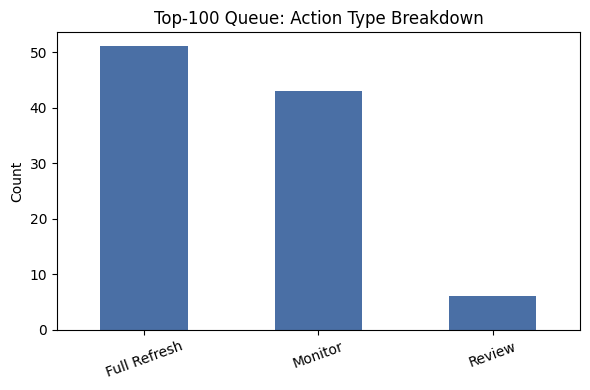

In [52]:
# --- 3. Figures -> work/figures/ (committed) ---

# Figure A: action type breakdown in top-100 queue
fig, ax = plt.subplots(figsize=(6, 4))
ranked_queue['action_type'].value_counts().plot(kind='bar', ax=ax, color='#4a6fa5')
ax.set_title('Top-100 Queue: Action Type Breakdown')
ax.set_ylabel('Count')
ax.set_xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('work/figures/action_type_breakdown.png', dpi=150)
plt.show()

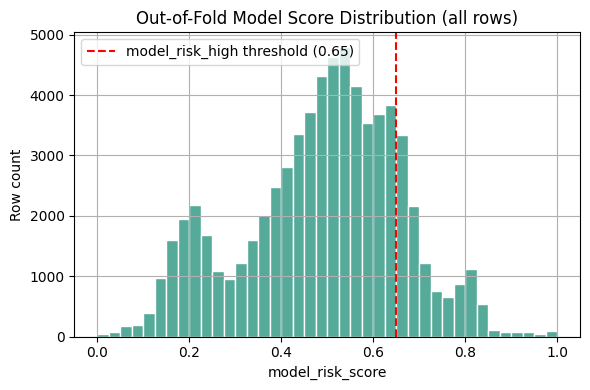


Figures saved to work/figures/. Queue + metrics saved to work/outputs/.
Reminder: commit work/figures/*.png and work/outputs/model_metrics.json to git.
Do NOT commit work/outputs/ranked_action_queue.csv — leak-guard blocks it, and it's meant to be regenerated, not tracked.


In [53]:
# Figure B: model score distribution, naive vs grouped context
fig, ax = plt.subplots(figsize=(6, 4))
df['model_risk_score'].hist(bins=40, ax=ax, color='#5a9', edgecolor='white')
ax.axvline(0.65, color='red', linestyle='--', label='model_risk_high threshold (0.65)')
ax.set_title('Out-of-Fold Model Score Distribution (all rows)')
ax.set_xlabel('model_risk_score')
ax.set_ylabel('Row count')
ax.legend()
plt.tight_layout()
plt.savefig('work/figures/score_distribution.png', dpi=150)
plt.show()

print("\nFigures saved to work/figures/. Queue + metrics saved to work/outputs/.")
print("Reminder: commit work/figures/*.png and work/outputs/model_metrics.json to git.")
print("Do NOT commit work/outputs/ranked_action_queue.csv — leak-guard blocks it, and it's meant to be regenerated, not tracked.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.